In [1]:
# import external modules
import numpy, os

# Add Exasim to Python search path
cdir = os.getcwd(); ii = cdir.find("Exasim")
exec(open(cdir[0:(ii+6)] + "/install/setpath.py").read())

# import internal modules
import Preprocessing, Postprocessing, Gencode, Mesh
import netCDF4
import Utilities, PlotUtilities

==> Exasim frontends ...



In [2]:
# Create pde object and mesh object
pde,mesh = Preprocessing.initializeexasim()

# Define a PDE model: governing equations and boundary conditions
pde['model'] = "ModelD";       # ModelC, ModelD, ModelW
pde['modelfile'] = "pdemodel"; # name of a file defining the PDE model
pde['hybrid'] = 1;          # 0 -> LDG, 1 -> HDG

# Choose computing platform and set number of processors
pde['platform'] = "gpu"
pde['mpiprocs'] = 4
pde['cpucompiler']  = "CC"
pde['mpicompiler'] = "CC"
pde['gpucompiler'] = cdir[0:(ii+6)] + "/kokkos/bin/nvcc_wrapper" # e.g. /path_to_kokkos/bin/nvcc_wrapper

# Set discretization parameters, physical parameters, and solver parameters
pde['nd'] = 3
pde['porder'] = 2;         # polynomial degree
pde['pgauss'] = 2*pde['porder'] # number of Gauss points for quadrature
pde['tau'] = numpy.array([2.0]);            # DG stabilization parameter
pde['GMRESrestart'] = 250; # GMRES restart parameter
pde['GMRESortho'] = 1
pde['linearsolvertol'] = 1e-6; # linear solver tolerance
pde['linearsolveriter'] = 500
pde['preconditioner'] = 1
pde['ppdegree'] = 0; # degree of polynomial precontiditoning
pde['RBdim'] = 0; # reduced basis dimension for preconditioner
pde['NLtol'] = 1e-7; # nonlinear solver tolerance
pde['NLiter'] = 10; # number of nonlinear iterations
pde['matvectol'] = 1e-6; # matrix-vector product tolerance

# Physical parameters
dt0 = 60.0  # time step size in seconds

Re = 6378e3
hL = 100e3; hT = 500e3

gam = 5/3
m = 16*1.67e-27
kB = 1.38e-23
e = 1.602e-19
g0 = 9.81*Re*Re/(Re + hL)**2
omega = 2*numpy.pi/86400
T0 = 200.0
B0 = 7.94e-15/(Re + hL)**3      # mu0*M/(4*pi*r**3), M = 7.94e22 Am^2, mu0 = 4*pi*1e-7
E0 = 0.0

H0 = kB*T0/(m*g0)
v0 = numpy.sqrt(gam*kB*T0/m)
t0 = H0/v0

# Nondimensional parameters
R0 = (Re + hL)/H0
R1 = (Re + hT)/H0

Ro = v0/(omega*H0)
piE = e*E0/(gam*m*g0)
piB = e*B0*v0/(gam*m*g0)
piNu = 0.0 # nu0*H0/v0
piChem = 0.0 # Ch0*H0/v0
Diff = 0.0 # kappa0/(n0*kB*v0*H0)
piP = 0.0 # P0*H0/(v0*T0)

pde['physicsparam'] = numpy.array([gam, Ro, piE, piB, piNu, piChem, Diff, piP, R0, R1, H0]);   # unit thermal conductivity
                                  #  0,  1,   2,   3,    4,      5,    6,    7,  8,  9, 10

# Time-stepping parameters
pde['torder'] = 1;          # time-stepping order of accuracy
pde['nstage'] = 1;          # time-stepping number of stages
pde['dt'] = (dt0/t0)*numpy.ones(10);   # time step sizes
pde['soltime'] = numpy.arange(1,pde['dt'].size+1,1); # steps at which solution are collected
pde['visdt'] = 1.0; # visualization timestep size

# Mesh generation
mesh['p'], mesh['t'], mesh['dgnodes'] = Mesh.cubesphere(pde['porder'],R0,R1,16,10)
mesh['boundaryexpr'] = [
    lambda p: abs(p[0,:]**2 + p[1,:]**2 + p[2,:]**2 - R0**2) < 1e-6,
    lambda p: abs(p[0,:]**2 + p[1,:]**2 + p[2,:]**2 - R1**2) < 1e-6]
mesh['boundarycondition'] = numpy.array([1, 2]); # Set boundary condition for each boundary

# Defining dipole magnetic field (test)
npe, nd, ne = mesh['dgnodes'].shape
x1 = mesh['dgnodes'][:,0,:]; x2 = mesh['dgnodes'][:,1,:]; x3 = mesh['dgnodes'][:,2,:]
r = numpy.sqrt(x1**2 + x2**2 + x3**2)
Bx = 3*x1*x3/r**2; By = 3*x2*x3/r**2; Bz = (3*x3**2 - r**2)/r**2
Bx = Bx*(R0/r)**3; By = By*(R0/r)**3; Bz = Bz*(R0/r)**3

mesh['vdg'] = numpy.zeros((npe,6,ne))
mesh['vdg'][:,0,:] = Bx
mesh['vdg'][:,1,:] = By
mesh['vdg'][:,2,:] = Bz
mesh['vdg'][:,3,:] = 0.0    # Ex
mesh['vdg'][:,4,:] = 0.0    # Ey
mesh['vdg'][:,5,:] = 0.0    # Ez

In [17]:
xpe,telem = Preprocessing.masternodes(pde['porder'],pde['nd'],pde['elemtype'])[0:2];
cgnodes, cgelcon, cgcells, celltype = Postprocessing.createcggrid(mesh['dgnodes'],telem)[0:4];

npe, nd, ne = mesh['dgnodes'].shape
npcg = cgnodes.shape[0]

xcg = cgnodes[:,0]; ycg = cgnodes[:,1]; zcg = cgnodes[:,2]
rcg = numpy.sqrt(xcg**2 + ycg**2 + zcg**2)
latcg = numpy.rad2deg(numpy.arcsin(zcg/rcg))
loncg = numpy.rad2deg(numpy.arctan2(ycg,xcg))

vardg = numpy.zeros((npe,1,ne))
for i in range(ne):
    vardg[:, :, i] = varout[cgelcon[:, i], 0][:, None]

/glade/derecho/scratch/jvilap/tmp/ipykernel_11691/3172896234.py:16: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  alt3d = data['ZG'][timeidx, :, :, :].filled() * 1e-2
/glade/derecho/scratch/jvilap/tmp/ipykernel_11691/3172896234.py:17: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  varin = data['OP'][timeidx, :, :, :].filled()


Text(0.5, 1.0, 'Altitude: 500.0 km')

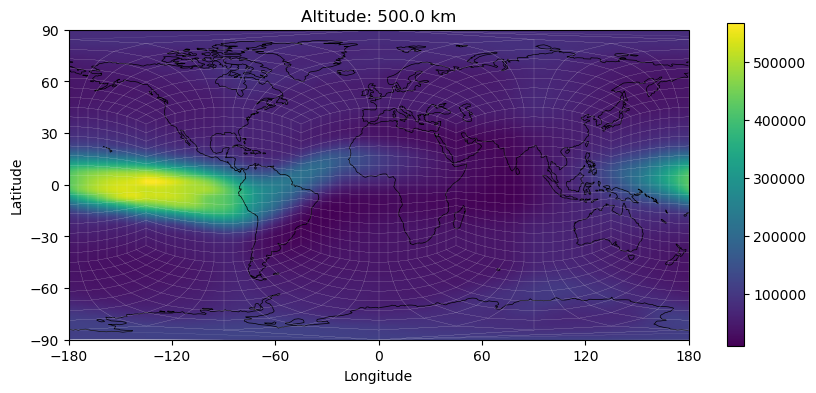

In [20]:
ilev = -1
xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(mesh['dgnodes'],vardg[:,0,:],pde,ilev)
fig, ax = PlotUtilities.plotslice(xcg2d,ucg2d, xgrid, coastlines=True, coastcolor='k', coastlw=0.5, color='w', lw=0.05)
ax.set_title(f'Altitude: {(altitude*H0 - Re)/1000:.1f} km')

p2 = mesh['dgnodes'][([0,2,8,6,18,20,26,24]),:,:].transpose(1, 0, 2).reshape(3, -1)